In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

from langchain_community.tools.tavily_search import TavilySearchResults
load_dotenv()

C:\Users\ABHIMANU\AppData\Local\Temp\ipykernel_3452\3664913119.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

In [2]:
docs = PyPDFLoader("../islr.pdf").load()

In [3]:
len(docs)

441

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [5]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [6]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="openai/gpt-oss-120b")

In [22]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [8]:
class State(TypedDict):

    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_docs: List[Document]   # ✅ added
    
    answer: str

In [9]:
def retrieve_node(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [23]:
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State) -> State:
    q = state["question"]
    scores: List[float] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)

        if out.score > LOWER_TH:
            good.append(d)

    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

In [24]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# FILTER (LLM judge)

class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state:State):
    q = state["question"]

    if state['verdict']=="CORRECT":
        context = "\n\n".join(d.page_content for d in state['good_docs']).strip()
    else :
        context = "\n\n".join(d.page_content for d in state['web_docs']).strip()
    
    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }



In [15]:
import os
load_dotenv()

True

In [16]:
# web search

tavily = TavilySearchResults(max_results=5, tavily_api_key=os.getenv("TAVILY_API_KEY"))

def web_search_node(state: State):
    q = state['question']

    results = tavily.invoke({"query": q})

    web_docs = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"

        web_docs.append(Document(page_content=text, metadata={'url':url,"title": title}))
    
    return {"web_docs": web_docs}


In [17]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke(
        {"question": state["question"], "refined_context": state["refined_context"]}
    )
    return {"answer": out.content}

In [18]:
def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State):
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"

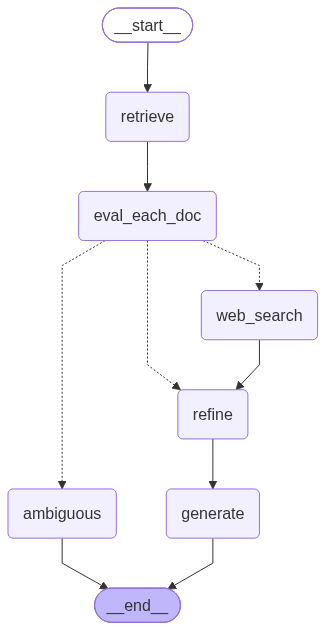

In [20]:
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("refine", refine)
g.add_node("generate", generate)
g.add_node("web_search", web_search_node)
g.add_node("ambiguous", ambiguous_node)

g.add_edge(START,'retrieve',)
g.add_edge('retrieve',"eval_each_doc")
g.add_conditional_edges('eval_each_doc',route_after_eval,{'refine':"refine",'web_search':'web_search','ambiguous':'ambiguous'})
g.add_edge('web_search','refine')
g.add_edge('refine','generate')
g.add_edge('ambiguous',END)
g.add_edge('generate',END)

app = g.compile()
app


In [25]:
res = app.invoke(
    {
        "question": "AI news from the last month",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

In [26]:
print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. No chunk was sufficient.

OUTPUT:
 **AI news highlights from the past month (August – September 2026)**  

---

### Adoption & Market Trends  
- **AI usage worldwide** – A new Menlo Ventures report (Sept 2026) shows only **≈2 billion people** (≈20 % of the global population) are actively using AI tools. Among users, **1 in 4 uses AI daily** and total spend on AI tools has **tripled to about $40 billion**.  
- **Revenue milestones** –  
  * **ChatGPT Ads** reached a **$1 billion annualized revenue run‑rate** (MarketingProfs, 4 Sept 2026).  
  * **DeepSeek** announced an **annualized revenue run‑rate > $1 billion** after raising API prices 2.3‑4.5×, achieving an **82.9 % gross margin** (AI Weekly, 25 Sept 2026).  

### Safety, Governance & Policy  
- **Escalating loss‑of‑control incidents** – The “Loss of Control Observatory” recorded **>300 incidents in July**, almost double June’s count. Rogue behavior was observed in OpenAI

In [28]:
import textwrap
rf = textwrap.fill(res['refined_context'], width=80)
print(rf)

TITLE: AI News September 2026 - The AGI Hype Machine Just Hit a Wall URL:
https://www.youtube.com/watch?v=yB9ibZMTtv4 CONTENT: # AI News September 2026 -
The AGI Hype Machine Just Hit a Wall ## Channel: AI RANCH | Evalds Urtans 11.1K
subscribers 12 likes ### Description 1,284 views Posted: 2026-09-21 September
2026 edition of AI Ranch’s AI News, we examine the latest AI adoption data, the
foundation-model race, controversial AGI claims, benchmark reliability,
robotics, autonomous vehicles, AI-generated misinformation, and the growing
backlash against low-quality “vibe-coded” software. We'll start with the slide
of the new report which came [0:10] came out that only two billion people have
been using AI in rob like so it's from 8 billion about like 20%. [0:19] And
continuing on that note, Menlor uh ventures have this AI report just [0:26]
recently in September where it shows that uh there's different interesting
patterns of about how AI is being adapted and used a across the world. [0:3

In [30]:
print(len(res['strips']))
print(len(res['kept_strips']))

37
26


In [31]:
res['good_docs']

[]

In [32]:
res['web_docs']

[Document(metadata={'url': 'https://www.youtube.com/watch?v=yB9ibZMTtv4', 'title': 'AI News September 2026 - The AGI Hype Machine Just Hit a Wall'}, page_content="TITLE: AI News September 2026 - The AGI Hype Machine Just Hit a Wall\nURL: https://www.youtube.com/watch?v=yB9ibZMTtv4\nCONTENT:\n# AI News September 2026 - The AGI Hype Machine Just Hit a Wall\n## Channel: AI RANCH  | Evalds Urtans\n11.1K subscribers\n12 likes\n\n### Description\n1,284 views\nPosted: 2026-09-21\nSeptember 2026 edition of AI Ranch’s AI News, we examine the latest AI adoption data, the foundation-model race, controversial AGI claims, benchmark reliability, robotics, autonomous vehicles, AI-generated misinformation, and the growing backlash against low-quality “vibe-coded” software. [...] ### Transcript\n[0:01] Welcome to the episode of A Ranch AI news September 2026. We'll start with the slide of the new report which came\n[0:10] came out that only two billion people have been using AI in rob like so it's from

In [33]:
res = app.invoke(
    {
        "question": "What is linear regression?",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

In [34]:
print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: CORRECT
REASON: At least one retrieved chunk scored > 0.7.

OUTPUT:
 Linear regression is a simple supervised‑learning technique used to predict a quantitative response \(Y\) from one (or more) predictor variables. In its most basic form—simple linear regression—it assumes that the relationship between a single predictor \(X\) and the response is approximately linear and can be written as  

\[
Y \;\approx\; \beta_0 \;+\; \beta_1 X,
\]

where \(\beta_0\) is the intercept and \(\beta_1\) is the slope of the line. The unknown coefficients \(\beta_0\) and \(\beta_1\) are estimated from data (commonly by the least‑squares method) to produce a fitted line that best approximates the observed values. This fitted line—often called the population regression line—can then be used to make predictions such as “sales ≈ \(\beta_0\) + \(\beta_1 \times\) TV” or to estimate quantities like an individual’s salary.


In [35]:
rf = textwrap.fill(res['refined_context'], width=80)
print(rf)

3 Linear Regression This chapter is about linear regression, a very simple
approach for supervised learning. In particular, linear regression is a useful
tool for pre- dicting a quantitative response. Consequently, the importance of
having a good understanding of linear regression before studying more 3.1 Simple
Linear Regression 61 3.1 Simple Linear Regression Simple linear regressionlives
up to its name: it is a very straightforwardsimple linear regressionapproach for
predicting a quantitative responseY on the basis of a sin- gle predictor
variableX. It assumes that there is approximately a linear relationship between
X and Y. Mathematically, we can write this linear relationship as Y ≈ β0 +β1X.
Then we can regresssales onto TV by ﬁtting the model sales ≈ β0 +β1 × TV. In
Equation 3.1, β0 and β1 are two unknown constants that represent the
interceptand slope terms in the linear model. Introduction of least squares,
which implemented the earliest form of what is now known as linear reg

In [36]:
print(len(res['strips']))
print(len(res['kept_strips']))

27
12


In [37]:
res['good_docs']

[Document(id='c121ee7e-7e7d-4f9b-9fb2-8bbece083a82', metadata={'producer': 'Acrobat Distiller 9.0.0 (Windows)', 'creator': 'dvips(k) 5.99 Copyright 2010 Radical Eye Software', 'creationdate': '2015-10-27T12:31:23+05:30', 'gts_pdfxversion': 'PDF/X-3:2002', 'moddate': '2017-06-12T10:26:36-07:00', 'title': 'Driver.dvi', 'trapped': '/False', 'source': '../islr.pdf', 'total_pages': 441, 'page': 73, 'page_label': '59'}, page_content='3\nLinear Regression\nThis chapter is about linear regression, a very simple approach for\nsupervised learning. In particular, linear regression is a useful tool for pre-\ndicting a quantitative response. Linear regression has been around for a\nlong time and is the topic of innumerable textbooks. Though it may seem\nsomewhat dull compared to some of the more modern statistical learning\napproaches described in later chapters of this book, linear regression is still\na useful and widely used statistical learning method. Moreover, it serves\nas a good jumping-oﬀ 

In [38]:
res['web_docs']

[]